In [129]:
import pandas as pd
from sklearn.model_selection import train_test_split
import plotly.express as px
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [15]:
df = pd.read_csv('data/penguins.csv')
df

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE
2,Adelie,Torgersen,40.3,18.0,195,3250,FEMALE
3,Adelie,Torgersen,36.7,19.3,193,3450,FEMALE
4,Adelie,Torgersen,39.3,20.6,190,3650,MALE
...,...,...,...,...,...,...,...
328,Gentoo,Biscoe,47.2,13.7,214,4925,FEMALE
329,Gentoo,Biscoe,46.8,14.3,215,4850,FEMALE
330,Gentoo,Biscoe,50.4,15.7,222,5750,MALE
331,Gentoo,Biscoe,45.2,14.8,212,5200,FEMALE


In [31]:
df_encoded = df.copy()

for col in ['sex','island']:
    encoder = LabelEncoder()
    encoder.fit(df_encoded[col])             
    df_encoded[col] = encoder.transform(df_encoded[col]) 

In [27]:
y = df_encoded ['species']
X = df_encoded.drop(columns = ['species'])
X

,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,2,39.1,18.7,181,3750,1
1,2,39.5,17.4,186,3800,0
2,2,40.3,18.0,195,3250,0
3,2,36.7,19.3,193,3450,0
4,2,39.3,20.6,190,3650,1
...,...,...,...,...,...,...
328,0,47.2,13.7,214,4925,0
329,0,46.8,14.3,215,4850,0
330,0,50.4,15.7,222,5750,1
331,0,45.2,14.8,212,5200,0


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 77, test_size = 0.2, stratify = y)

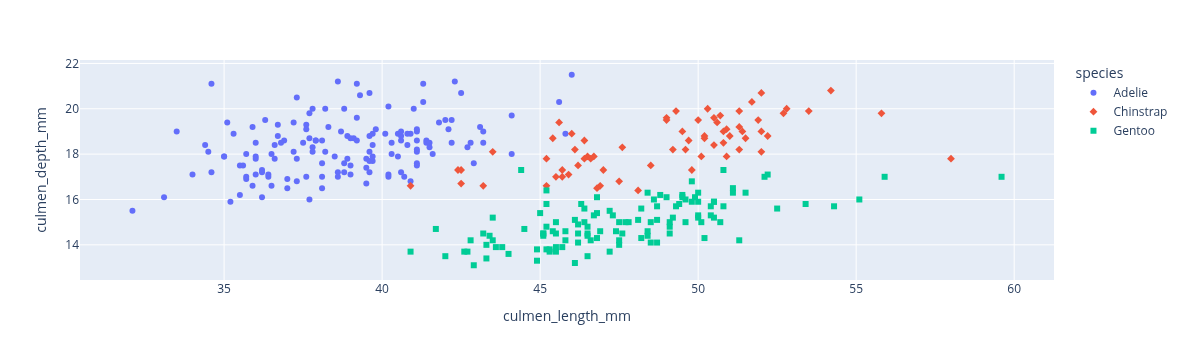

In [49]:
fig = px.scatter(df, x="culmen_length_mm", y="culmen_depth_mm", color="species",symbol="species")
fig.show()

In [93]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [94]:
clf = MLPClassifier(random_state = 1, max_iter = 300)

In [97]:
clf.fit(X_train_scaled,y_train)

MLPClassifier(max_iter=300, random_state=1)

### Пресметајте ја прецизноста на мрежата за податоците кои мрежата ги нема видено (на кои нема тренирано). Потоа пресметајте ја прецизноста на мрежата за податоците кои ги има видено (на кои има тренирано). Споредете ги резултатите.

In [99]:
print('Training set accuracy:', accuracy_score(y_true = y_train, y_pred = clf.predict(X_train_scaled)))

Training set accuracy: 1.0


In [100]:
print('Testing set accuracy:', accuracy_score(y_true = y_test, y_pred = clf.predict(X_test_scaled)))

Testing set accuracy: 0.9850746268656716


#### Кои пингвини мрежата успева да ги распознава подобро, машките или женските?

In [125]:
mask_male = (X_test ['sex'] == 1)
mask_female = (X_test ['sex'] == 0)
X_male = X_test[mask_male]
X_female = X_test[mask_female]

In [137]:
y_male = y_test[mask_male]
y_female = y_test[mask_female]

In [138]:
X_female_scaled = scaler.transform(X_female)

In [140]:
print('Female data accuracy:', accuracy_score(y_true = y_female, y_pred = clf.predict(X_female_scaled)))

Female data accuracy: 0.9459459459459459


In [135]:
X_male_scaled =  scaler.transform(X_male)

In [142]:
print('Male data accuracy:', accuracy_score(y_true = y_male, y_pred = clf.predict(X_male_scaled)))

Male data accuracy: 1.0


In [143]:
from sklearn.metrics import confusion_matrix

cm_male = confusion_matrix(y_true=y_male, y_pred=clf.predict(X_male_scaled))
cm_female = confusion_matrix(y_true=y_female, y_pred=clf.predict(X_female_scaled))

print('Confusion matrix - машки:\n', cm_male)
print('Confusion matrix - женски:\n', cm_female)

Confusion matrix - машки:
 [[13  0  0]
 [ 0  6  0]
 [ 0  0 11]]
Confusion matrix - женски:
 [[16  0  0]
 [ 2  6  0]
 [ 0  0 13]]


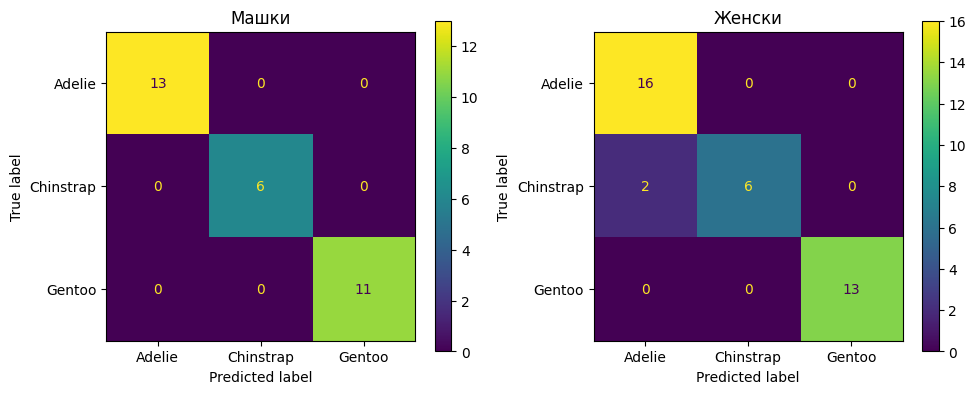

In [146]:
import matplotlib.pyplot as plt

labels = sorted(y_test.unique())
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_male, display_labels=labels).plot(ax=axes[0])
axes[0].set_title('Машки')
ConfusionMatrixDisplay(cm_female, display_labels=labels).plot(ax=axes[1])
axes[1].set_title('Женски')
plt.tight_layout()
plt.show()

### Од кој вид е даден машки пингвин со признаци `culmen_length_mm = 72`, `culmen_depth_mm = 34`, `flipper_length_mm = 202`, `body_mass_g = 4450`, и е пронајден на островот Торгерсен?

In [153]:
novo_bate = pd.DataFrame([{
    'island': 2,            # Торгерсен во LabelEncoder беше 2
    'culmen_length_mm': 72.0,
    'culmen_depth_mm': 34.0,
    'flipper_length_mm': 202.0,
    'body_mass_g': 4450.0,
    'sex': 1                # Машки пол во LabelEncoder беше 1
}])
novo_bate_scaled = scaler.transform( novo_bate )
class_prediction = clf.predict(novo_bate_scaled)

print('Ова бате пингвин е од видот:', class_prediction[0])

Ова бате пингвин е од видот: Chinstrap
